In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns


# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
import pandas as pd

df = pd.read_csv("taiwanese-food-101/tw_food_101_classes.csv", header=None)

total_classes = df[1].tolist()

print(total_classes)  # 確保讀取正確

['bawan', 'beef_noodles', 'beef_soup', 'bitter_melon_with_salted_eggs', 'braised_napa_cabbage', 'braised_pork_over_rice', 'brown_sugar_cake', 'bubble_tea', 'caozaiguo', 'chicken_mushroom_soup', 'chinese_pickled_cucumber', 'coffin_toast', 'cold_noodles', 'crab_migao', 'deep-fried_chicken_cutlets', 'deep_fried_pork_rib_and_radish_soup', 'dried_shredded_squid', 'egg_pancake_roll', 'eight_treasure_shaved_ice', 'fish_head_casserole', 'fried-spanish_mackerel_thick_soup', 'fried_eel_noodles', 'fried_instant_noodles', 'fried_rice_noodles', 'ginger_duck_stew', 'grilled_corn', 'grilled_taiwanese_sausage', 'hakka_stir-fried', 'hot_sour_soup', 'hung_rui_chen_sandwich', 'intestine_and_oyster_vermicelli', 'iron_egg', 'jelly_of_gravey_and_chicken_feet_skin', 'jerky', 'kung-pao_chicken', 'luwei', 'mango_shaved_ice', 'meat_dumpling_in_chili_oil', 'milkfish_belly_congee', 'mochi', 'mung_bean_smoothie_milk', 'mutton_fried_noodles', 'mutton_hot_pot', 'nabeyaki_egg_noodles', 'night_market_steak', 'nougat',

In [3]:
import os
import warnings
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, class_map_file=None, transform=None, subset=None, validation_split=0.1, seed=42):
        """
        Args:
            csv_file (str): 影像數據的 CSV，包含 [Index, Label, ImagePath]
            root_dir (str): 影像資料的根目錄
            class_map_file (str, optional): Class 對應的 CSV，包含 [Index, ClassName]，可選
            transform (callable, optional): 圖像轉換，如 ToTensor(), Resize() 等
            subset (str, optional): 選擇 'train'、'validation' 或 'test'
            validation_split (float, optional): 設定驗證集比例（0-1 之間）
            seed (int, optional): 隨機種子，確保可重現性
        """
        self.root_dir = root_dir
        self.transform = transform
        self.subset = subset
        self.seed = seed

        # 讀取 CSV，處理標籤
        self.data_frame = pd.read_csv(csv_file, header=None, names=["Index", "Label", "ImagePath"])

        # 讀取 Class Map（如果有提供）
        if class_map_file:
            class_map_df = pd.read_csv(class_map_file, header=None, names=["Index", "ClassName"])
            self.int_to_class = {row["Index"]: row["ClassName"] for _, row in class_map_df.iterrows()}
            self.class_to_int = {row["ClassName"]: row["Index"] for _, row in class_map_df.iterrows()}
        else:
            self.int_to_class = None
            self.class_to_int = None

        # 檢查是否為測試集
        self.is_test_set = self.data_frame["Label"].isna().all()

        # 如果不是測試集，進行訓練/驗證拆分
        if not self.is_test_set and subset in ["train", "validation"]:
            train_data, val_data = train_test_split(
                self.data_frame, test_size=validation_split, random_state=self.seed, stratify=self.data_frame["Label"]
            )
            self.data_frame = train_data if subset == "train" else val_data

    def __len__(self):
        return len(self.data_frame)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.data_frame.iloc[idx, 2])  # 读取图片路径

        retries = 0
        max_retries = 5

        while retries < max_retries:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    image = Image.open(img_path)

                # 修正透明度问题
                if image.mode in ["P", "LA", "RGBA"]:
                    image = image.convert("RGB")
                                
                elif image.mode == "CMYK":
                    image = image.convert("RGB")  # 将 CMYK 转为 RGB

                if self.transform:
                    image = self.transform(image)

                # 测试集没有标签
                label = None if self.is_test_set else int(self.data_frame.iloc[idx, 1])
                return image, label

            except Exception as e:
                print(f"⚠️ 警告: 无法读取 {img_path}，错误信息: {e}")
                retries += 1
                # 如果读取出错，跳过该图片
                if retries >= max_retries:
                    print(f"跳过图片: {img_path}")
                    # 返回一个全零的假图片来避免返回 None
                    dummy_image = Image.new('RGB', (224, 224), (0, 0, 0))  # 创建一个全黑的图片
                    dummy_label = -1  # 假标签
                    if self.transform:
                        dummy_image = self.transform(dummy_image)  # 应用相同的 transform
                    return dummy_image, dummy_label  # 返回默认的无效数据

        # 如果超过最大重试次数还是无法读取图片，抛出异常
        raise RuntimeError(f"❌ 无法读取图片: {img_path}，已达最大重试次数 {max_retries} 次。")


    def get_class_name(self, label_int):
        """ 傳入數字標籤，回傳對應的食物名稱 """
        if self.int_to_class:
            return self.int_to_class.get(label_int, "Unknown")
        return str(label_int)

    def get_class_int(self, class_name):
        """ 傳入食物名稱，回傳對應的數字標籤 """
        if self.class_to_int:
            return self.class_to_int.get(class_name, -1)
        return -1


In [4]:
csv_path = "taiwanese-food-101/tw_food_101/tw_food_101/tw_food_101_train.csv"  # 訓練數據 CSV
test_csv_path = "taiwanese-food-101/tw_food_101/tw_food_101/tw_food_101_test_list.csv"  # 測試數據 CSV
root_dir = "taiwanese-food-101/tw_food_101/tw_food_101/"  # 影像根目錄
class_map_file = "taiwanese-food-101/tw_food_101_classes.csv"  # Class 標籤對應表

In [ ]:
# 設定轉換（對於圖像大小、標準化等處理）
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # 增加翻轉機率，通常水平翻轉比較常見
    transforms.RandomRotation(degrees=15),  # 限制旋轉範圍，避免過度扭曲圖片
    transforms.AutoAugment(),  # 可以保留，也可以選擇不使用
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 使用隨機裁剪來強化模型
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ViT 預訓練標準化
])

# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),  # 增加翻轉機率，水平翻轉對食物圖片有幫助
#     transforms.RandomRotation(degrees=10),  # 限制旋轉範圍，避免過度扭曲圖片
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 隨機裁剪，避免過度變形
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 隨機調整顏色，增強顏色變化
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 使用 ViT 預訓練標準化
# ])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Vit
    transforms.ToTensor(),  # 轉換為 Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# 訓練集 (90%)
train_ds = CustomImageDataset(csv_file=csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                              transform=train_transform, subset='train')

# 驗證集 (10%)
val_ds = CustomImageDataset(csv_file=csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                            transform=val_transform, subset='validation')

test_ds = CustomImageDataset(csv_file=test_csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                             transform=val_transform, subset='test')


# 使用 DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4, pin_memory= True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory= True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory= True)
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))


18334
2038
5093


Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])
First label in batch: 18


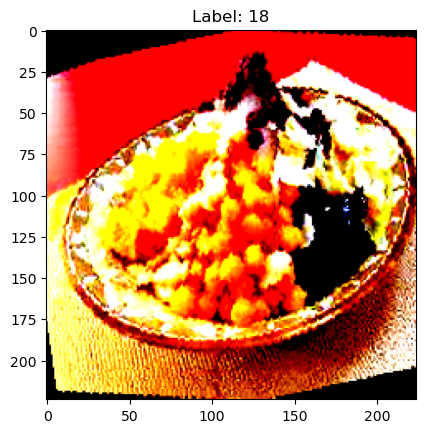

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 顯示第一個批次中的第一張圖片
for images, labels in train_loader:
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"First label in batch: {labels[0]}")  # 查看第一個圖片的標籤
    
    # 顯示第一張圖片
    first_image = images[0].permute(1, 2, 0).numpy()  # 將 Tensor 轉換為 NumPy 陣列並調整通道順序 (C, H, W) -> (H, W, C)
    first_image = np.clip(first_image, 0, 1)  # 確保數值在 0 到 1 之間
    plt.imshow(first_image)
    plt.title(f"Label: {labels[0]}")
    plt.show()
    break  # 只顯示第一個批次，防止繼續遍歷

In [ ]:
# 定義 Vision Transformer 模型
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

model.heads[0] = nn.Sequential(
    nn.Dropout(p=0.2),  # 加入 Dropout 層
    nn.Linear(model.heads[0].in_features, len(total_classes))
)

model.to(device)

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), weight_decay=0.01, lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)
#Vit 80%

# # 定義 Vision Transformer 模型
# model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# # 修改模型的頭部，增加更多層
# model.heads[0] = nn.Sequential(
#     nn.Dropout(p=0.2),  # 加入 Dropout 層
#     nn.Linear(model.heads[0].in_features, 512),  # 新的全連接層，將特徵維度降低
#     nn.ReLU(),  # 添加 ReLU 激活函數
#     nn.Dropout(p=0.3),  # 進一步加強 Dropout
#     nn.Linear(512, 256),  # 再加一層全連接層
#     nn.ReLU(),  # 添加 ReLU 激活函數
#     nn.Dropout(p=0.4),  # 更強的 Dropout
#     nn.Linear(256, len(total_classes))  # 最後一層輸出層，對應所有類別
# )

# model.to(device)

# # 定義損失函數和優化器
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model.parameters(), weight_decay=0.01, lr=1e-4)

# # 使用 ReduceLROnPlateau 學習率調度器
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)

In [8]:

import warnings
from PIL import Image
from tqdm import tqdm  # ✅ 引入 tqdm 來顯示進度條
torch.cuda.empty_cache()  # 清空 CUDA Cache
torch.cuda.memory_reserved(0)  # 釋放所有 GPU 記憶體

warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

# 自定義 Logger
class EpochLogger:
    def __init__(self):
        self.history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    def log_epoch(self, epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time):
        self.history["loss"].append(train_loss)
        self.history["accuracy"].append(train_accuracy)
        self.history["val_loss"].append(val_loss)
        self.history["val_accuracy"].append(val_accuracy)

        print(f"\nEpoch {epoch + 1}:")
        print(f"  - Train Loss: {train_loss:.4f}")
        print(f"  - Train Accuracy: {train_accuracy:.4f}")
        print(f"  - Val Loss: {val_loss:.4f}")
        print(f"  - Val Accuracy: {val_accuracy:.4f}")
        print(f"  - Epoch Time: {epoch_time:.2f} seconds", flush=True)  # ✅ 確保即時輸出

# 訓練模型
num_epochs = 100
best_val_accuracy = 0.0
epoch_logger = EpochLogger()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    start_time = time.time()

    # ✅ 使用 tqdm 來顯示 batch 訓練進度
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        # ✅ 更新 tqdm 進度條顯示 loss
        train_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_train / total_train)

    train_loss /= total_train
    train_accuracy = correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc=f"Validation {epoch+1}/{num_epochs}", leave=False)  # ✅ Validation 也加進度條

        for inputs, labels in val_loader_tqdm:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            # ✅ 更新 tqdm 進度條顯示 loss
            val_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_val / total_val)

    val_loss /= total_val
    val_accuracy = correct_val / total_val

    epoch_time = time.time() - start_time
    epoch_logger.log_epoch(epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time)

    # 獲取當前學習率
    # current_lr = scheduler.get_last_lr()[0]  
    # print(f"Current LR: {current_lr:.6f}")

    # scheduler.step(val_loss)

    # ✅ 保存最佳模型
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "hw2_weight/revise_Vit_schedular.pth")

print(f"\n best_val_accuracy: {best_val_accuracy}")
print("\n🎉 Training Complete.")


Epoch 1/100: 100%|██████████| 1146/1146 [01:58<00:00,  9.70it/s, accuracy=0.338, loss=1.79] 
                                                                                               


Epoch 1:
  - Train Loss: 2.9193
  - Train Accuracy: 0.3376
  - Val Loss: 1.3369
  - Val Accuracy: 0.6546
  - Epoch Time: 125.92 seconds


Epoch 2/100: 100%|██████████| 1146/1146 [01:58<00:00,  9.65it/s, accuracy=0.717, loss=0.383]
                                                                                               


Epoch 2:
  - Train Loss: 1.0707
  - Train Accuracy: 0.7167
  - Val Loss: 1.0100
  - Val Accuracy: 0.7237
  - Epoch Time: 126.33 seconds


Epoch 3/100: 100%|██████████| 1146/1146 [02:00<00:00,  9.51it/s, accuracy=0.791, loss=1.52] 
                                                                                               

...


Epoch 98:
  - Train Loss: 0.0648
  - Train Accuracy: 0.9803
  - Val Loss: 1.1770
  - Val Accuracy: 0.7512
  - Epoch Time: 116.55 seconds


Epoch 99/100: 100%|██████████| 1146/1146 [01:49<00:00, 10.46it/s, accuracy=0.977, loss=0.0915]  
                                                                                                


Epoch 99:
  - Train Loss: 0.0752
  - Train Accuracy: 0.9774
  - Val Loss: 1.1095
  - Val Accuracy: 0.7547
  - Epoch Time: 117.17 seconds


Epoch 100/100: 100%|██████████| 1146/1146 [01:49<00:00, 10.49it/s, accuracy=0.98, loss=0.0299]  
                                                                                                  


Epoch 100:
  - Train Loss: 0.0656
  - Train Accuracy: 0.9802
  - Val Loss: 1.2362
  - Val Accuracy: 0.7453
  - Epoch Time: 116.75 seconds

 best_val_accuracy: 0.7919528949950932

🎉 Training Complete.
